TYPE: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "NAD_1983_Lambert_Conformal_Conic", "base_crs": {"name": "NAD83", "datum": {"type": "GeodeticReferenceFrame", "name": "North American Datum 1983", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}, "id": {"authority": "EPSG", "code": 6269}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Longitude", "abbreviation": "lon", "direction": "east", "unit": {"type": "AngularUnit", "name": "Degree", "conversion_factor": 0.0174532925199433}}, {"name": "Latitude", "abbreviation": "lat", "direction": "north", "unit": {"type": "AngularUnit", "name": "Degree", "conversion_factor": 0.0174532925199433}}]}}, "conversion": {"name": "unnamed", "method": {"name": "Lambert Conic Conformal (2SP)", "id": {"authority": "EPSG", "code": 9802}}, "parameters": [{"name": "Latitude of false ori

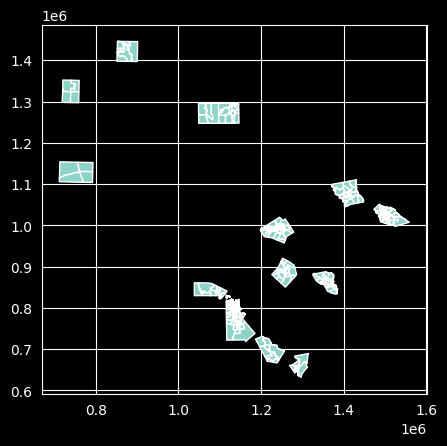

In [22]:
import geopandas as gpd
import pandas as pd

from texas_gerrymandering_hb4.config import ANALYSIS_READY_PARQUET, GEN_ELECTION_CSV

# 1) Read with geopandas
gdf = gpd.read_parquet(ANALYSIS_READY_PARQUET)

print("TYPE:", type(gdf))
print("CRS:", gdf.crs)
print("ACTIVE GEOMETRY:", gdf.geometry.name)
print("FIRST GEOMETRY PYTHON TYPE:", type(gdf.geometry.iloc[0]))
print("FIRST GEOMETRY GEOM_TYPE:", gdf.geometry.iloc[0].geom_type)
print("MISSING GEOMETRIES:", gdf.geometry.isna().sum())
print("INVALID GEOMETRIES:", (~gdf.is_valid).sum())

# 2) Make sure it can actually do geo operations
print("TOTAL BOUNDS:", gdf.total_bounds)

ax = gdf.head(500).plot()
print("PLOT OK")

In [23]:
vote_cols = [c for c in gdf.columns if c.endswith("_24G") or c.endswith("_24P") or c.startswith("TOTVOTE_")]

missing_summary = (
    gdf[vote_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print(missing_summary.head(20))

pct_missing_any = gdf[vote_cols].isna().any(axis=1).mean()
print("Percent of precincts with ANY missing election data:", pct_missing_any)

AllredD_24G         0.0
AndrusW_24G         0.0
BrownL_24G          0.0
CraddickR_24G       0.0
CruzR_24G           0.0
CulbertD_24G        0.0
DunlapL_24G         0.0
EspinozaG_24G       0.0
HarrisD_24G         0.0
McKibbinW_24G       0.0
OliverL_24G         0.0
RocheW_24G          0.0
SteinG_24G          0.0
TrumpR_24G          0.0
WriteInW_24G        0.0
TOTVOTE_PRES_24G    0.0
TOTVOTE_RRC_24G     0.0
TOTVOTE_SEN_24G     0.0
AllredD_24P         0.0
BidenD_24P          0.0
dtype: float64
Percent of precincts with ANY missing election data: 0.0


In [24]:
zero_summary = (gdf[vote_cols] == 0).mean().sort_values(ascending=False)
print(zero_summary.head(20))

AndrusW_24G         0.956343
RocheW_24G          0.928027
StuckenbergR_24P    0.810956
BinkleyR_24P        0.800247
HutchinsonR_24P     0.783567
McKibbinW_24G       0.753398
LockeD_24P          0.579901
LozadaD_24P         0.569605
ChristieR_24P       0.557146
UygurD_24P          0.553542
RamaswamyR_24P      0.532331
TchenkoD_24P        0.485585
CornejoD_24P        0.478480
WriteInW_24G        0.466433
PerezD_24P          0.442545
HassanD_24P         0.417525
PrillimanD_24P      0.401050
ShermanD_24P        0.358320
KeoughD_24P         0.352759
PhillipsD_24P       0.344625
dtype: float64


In [25]:
gdf[gdf["TOTVOTE_PRES_24G"] == 0].head()

,CNTYVTD,geometry,CD,TOTALPOP,CVAP,HCVAP,WCVAP,BCVAP,OCVAP,AllredD_24G,...,TrumpR_24P,UncommittedR_24P,UygurD_24P,WilliamsonD_24P,TOTVOTE_PRESD_24P,TOTVOTE_PRESR_24P,TOTVOTE_RRCD_24P,TOTVOTE_RRCR_24P,TOTVOTE_SEND_24P,TOTVOTE_SENR_24P
203,270117,"POLYGON ((1223183.045 997244.86, 1223180.34 99...",31,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,...,0,0,0,0,0,0,0,0,0,0
353,291101,"POLYGON ((1124842.696 809211.248, 1124842.928 ...",20,1.0,0.572124,0.287059,0.109930,0.124986,0.050149,0,...,0,0,0,0,0,0,0,0,0,0
358,291106,"POLYGON ((1123977.631 802768.363, 1123691.254 ...",23,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,...,0,0,0,0,0,0,0,0,0,0
379,291126,"POLYGON ((1147352.163 806299.688, 1147310.307 ...",20,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0,...,0,0,0,0,0,0,0,0,0,0
383,291130,"POLYGON ((1124787.213 810581.525, 1124817.249 ...",20,7.0,3.878442,2.084956,1.464406,0.282069,0.047011,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
election = pd.read_csv(GEN_ELECTION_CSV)

print("Unique precincts in shapefile:", gdf["CNTYVTD"].nunique())
print("Unique precincts in election data:", election["cntyvtd"].nunique())

matched = set(gdf["CNTYVTD"]) & set(election["cntyvtd"])
print("Matched precincts:", len(matched))

Unique precincts in shapefile: 9712
Unique precincts in election data: 9712
Matched precincts: 9712


In [27]:
tot_cols = [c for c in gdf.columns if c.startswith("TOTVOTE_")]
print((gdf[tot_cols] == 0).mean().sort_values(ascending=False))

TOTVOTE_RRCD_24P     0.070943
TOTVOTE_SEND_24P     0.070222
TOTVOTE_PRESD_24P    0.069502
TOTVOTE_RRCR_24P     0.054366
TOTVOTE_SENR_24P     0.052924
TOTVOTE_PRESR_24P    0.052409
TOTVOTE_RRC_24G      0.037788
TOTVOTE_PRES_24G     0.037479
TOTVOTE_SEN_24G      0.037376
dtype: float64
